## Name: Arendra Singh Rajput
## JLU ID : JLU08391
## Roll NO.: 2023BTCSE003
## Course : Soft Computing (EL1)
## Course Code: STDA2102



# ___

## Question 1:

To understand and implement the basic working of an artificial neuron using Python.

In [1]:
import numpy as np

# Define the step activation function
def step_activation(z):
    return 1 if z >= 0 else 0

In [2]:
# Define the artificial neuron function
def artificial_neuron(inputs, weights, bias, activation=step_activation):
    weighted_sum = np.dot(inputs, weights)
    z = weighted_sum + bias
    output = activation(z)
    return weighted_sum, z, output

In [3]:
# Demonstrate the basic working of a single neuron
inputs = np.array([0.5, 0.8])
weights = np.array([0.4, 0.7])
bias = -0.5

weighted_sum, z, output = artificial_neuron(inputs, weights, bias)

print(f"Inputs: {inputs}")
print(f"Weights: {weights}")
print(f"Bias: {bias}")
print(f"Weighted Sum (z): {z:.2f}")
print(f"Activation Output: {output}")

Inputs: [0.5 0.8]
Weights: [0.4 0.7]
Bias: -0.5
Weighted Sum (z): 0.26
Activation Output: 1


In [4]:
# Test with multiple input sets
test_cases = [
    np.array([0.1, 0.2, 0.3]),
    np.array([0.9, 0.9, 0.9]),
    np.array([-0.5, 0.4, 0.1]),
]
test_weights = np.array([0.4, 0.7, 0.5])  # 3-element weights to match 3-feature inputs
for i, x in enumerate(test_cases, start=1):
    ws, z, out = artificial_neuron(x, test_weights, bias)
    print(f"Case {i}: inputs={x}, z={round(z,4)}, output={out}")

Case 1: inputs=[0.1 0.2 0.3], z=-0.17, output=0
Case 2: inputs=[0.9 0.9 0.9], z=0.94, output=1
Case 3: inputs=[-0.5  0.4  0.1], z=-0.37, output=0


**Result:** The artificial neuron successfully calculates weighted sums and produces binary outputs using the step activation function.

---

## Question 2:

To implement the weighted sum of inputs and bias used in an artificial neuron using Python.

In [5]:
import numpy as np

# Function to calculate z = Σ(w * x) + b
def calculate_weighted_sum(inputs, weights, bias):
    return np.dot(inputs, weights) + bias

In [6]:
# Example with manual verification
x = np.array([1.0, 2.0, 3.0])
w = np.array([0.2, 0.5, -0.1])
b = 1.0

# Manual calculation for transparency
manual_z = (x[0]*w[0] + x[1]*w[1] + x[2]*w[2]) + b

# Using the function
z = calculate_weighted_sum(x, w, b)

print(f"Inputs: {x}")
print(f"Weights: {w}")
print(f"Bias: {b}")
print(f"Manual Result: {manual_z}")
print(f"Function Result: {z}")

Inputs: [1. 2. 3.]
Weights: [ 0.2  0.5 -0.1]
Bias: 1.0
Manual Result: 1.9
Function Result: 1.9


In [7]:
# Batch example: multiple samples
X = np.array([
    [1.0, 0.5, -1.0],
    [0.2, 0.8, 0.3],
    [-0.4, -0.6, 0.9],
])
w = np.array([0.5, -0.2, 0.7])
b = 0.1
print("\nBatch example: 3 samples, 3 features")
for i, row in enumerate(X, start=1):
    z = calculate_weighted_sum(row, w, b)
    print(f"Sample {i}: inputs={row}, z={round(z, 4)}")


Batch example: 3 samples, 3 features
Sample 1: inputs=[ 1.   0.5 -1. ], z=-0.2
Sample 2: inputs=[0.2 0.8 0.3], z=0.25
Sample 3: inputs=[-0.4 -0.6  0.9], z=0.65


**Result:** The weighted sum function correctly computes $z = \sum(wx) + b$ for individual inputs and batches of samples.

---

## Question 3:

To implement and visualize Sigmoid, Tanh, and ReLU activation functions using Python.

In [8]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x): return 1 / (1 + np.exp(-x))
def tanh(x): return np.tanh(x)
def relu(x): return np.maximum(0, x)

def sigmoid_der(x): s = sigmoid(x); return s * (1 - s)
def tanh_der(x): return 1 - np.tanh(x)**2
def relu_der(x): return np.where(x > 0, 1, 0)

In [9]:
# Demonstrate with sample values
x_samples = [-2, 0, 2]  # plain Python ints to avoid numpy int format issues
print("Sample values at x = -2, 0, 2:")
for val in x_samples:
    print(f"  x={val:>3}: sigmoid={sigmoid(val):.4f}, tanh={tanh(val):.4f}, relu={relu(val):.4f}")

Sample values at x = -2, 0, 2:
  x= -2: sigmoid=0.1192, tanh=-0.9640, relu=0.0000
  x=  0: sigmoid=0.5000, tanh=0.0000, relu=0.0000
  x=  2: sigmoid=0.8808, tanh=0.9640, relu=2.0000


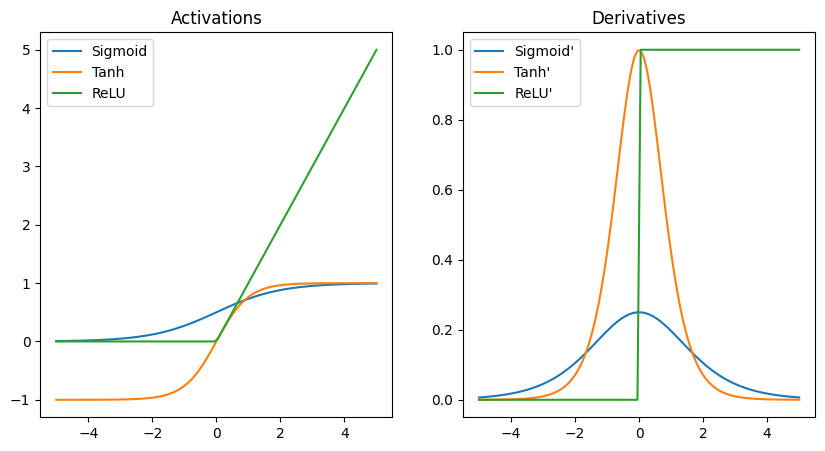

In [10]:
x = np.linspace(-5, 5, 100)
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.plot(x, sigmoid(x), label='Sigmoid')
plt.plot(x, tanh(x), label='Tanh')
plt.plot(x, relu(x), label='ReLU')
plt.title('Activations'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x, sigmoid_der(x), label='Sigmoid\'')
plt.plot(x, tanh_der(x), label='Tanh\'')
plt.plot(x, relu_der(x), label='ReLU\'')
plt.title('Derivatives'); plt.legend()

plt.show()

**Result:** Sigmoid, Tanh, and ReLU activation functions and their derivatives are successfully implemented and visualized.

---

## Question 4:

To create a simple single-layer neural network using Python.

In [11]:
import numpy as np

class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        self.w = np.zeros(n_inputs)
        self.b = 0.0
        self.lr = lr

    def predict(self, x):
        return 1 if (np.dot(x, self.w) + self.b) >= 0 else 0

    def train(self, X, y, epochs=10):
        for _ in range(epochs):
            for xi, target in zip(X, y):
                error = target - self.predict(xi)
                self.w += self.lr * error * xi
                self.b += self.lr * error


In [12]:
X = np.array([[0,0], [0,1], [1,0], [1,1]])
y = np.array([0, 0, 0, 1]) # AND gate

p = Perceptron(n_inputs=2)
p.train(X, y)

for xi in X:
    print(f"Input: {xi} Pred: {p.predict(xi)}")

Input: [0 0] Pred: 0
Input: [0 1] Pred: 0
Input: [1 0] Pred: 0
Input: [1 1] Pred: 1


In [13]:
# Test and display results
print("\nTesting the trained perceptron:")
for xi, target in zip(X, y):
    pred = p.predict(xi)
    status = "Correct" if pred == target else "WRONG"
    print(f"  Input={xi}, Target={target}, Predicted={pred}, {status}")


Testing the trained perceptron:
  Input=[0 0], Target=0, Predicted=0, Correct
  Input=[0 1], Target=0, Predicted=0, Correct
  Input=[1 0], Target=0, Predicted=0, Correct
  Input=[1 1], Target=1, Predicted=1, Correct


**Result:** The single-layer perceptron successfully learns and predicts the AND gate outputs.

---

## Question 5:

To create a Multilayer Perceptron (MLP) with input, hidden, and output layers using Keras/TensorFlow.

In [14]:
from tensorflow import keras
from tensorflow.keras import layers

X = np.array([[0,0], [0,1], [1,0], [1,1]], dtype='float32')
y = np.array([0, 1, 1, 0], dtype='float32') # XOR gate

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(4, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy')
model.fit(X, y, epochs=500, verbose=0)

print("XOR Predictions:", (model.predict(X) > 0.5).astype(int).flatten())

**Result:** The multilayer perceptron successfully learns the XOR relationship using hidden and output layers.

---

## Question 6:

To apply Gradient Descent for updating the weights of a simple neural network during training.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z): return 1 / (1 + np.exp(-z))

# Binary cross-entropy loss
def compute_loss(y_true, y_pred):
    return -np.mean(y_true * np.log(y_pred + 1e-9) + (1-y_true) * np.log(1-y_pred + 1e-9))

In [ ]:
# Training loop with Gradient Descent
X_q6 = np.array([0.1, 0.3, 0.6, 0.8, 1.2, 1.5, 1.8, 2.0])
y_q6 = np.array([0, 0, 0, 0, 1, 1, 1, 1], dtype=float)
w, b, lr = 0.0, 0.0, 0.5
losses = []

for _ in range(100):
    z = w * X_q6 + b
    y_p = sigmoid(z)
    losses.append(compute_loss(y_q6, y_p))
    dz = y_p - y_q6
    w -= lr * np.mean(dz * X_q6)
    b -= lr * np.mean(dz)

print(f"Trained Weight: {w:.4f}, Bias: {b:.4f}")
plt.plot(losses); plt.title("Loss Curve"); plt.show()

**Result:** Gradient Descent successfully updates the weight and bias while reducing the binary cross-entropy loss.

---

## Question 7:

To understand and implement the basic concept of Backpropagation for training a neural network.

In [ ]:
import numpy as np

def sig(z): return 1 / (1 + np.exp(-z))
def sig_d(a): return a * (1 - a)


In [ ]:
# Question 7: Forward and Backward passes
def backprop_step(X, y, w1, w2, lr=0.1):
    # Hidden layer
    z1 = np.dot(X, w1)
    a1 = sig(z1)
    # Output layer
    z2 = np.dot(a1, w2)
    a2 = sig(z2)
    # Backprop gradients
    d2 = (a2 - y) * sig_d(a2)
    d1 = np.dot(d2, w2.T) * sig_d(a1)
    w2 -= lr * np.dot(a1.T, d2)
    w1 -= lr * np.dot(X.T, d1)
    return np.mean((a2 - y)**2)

In [ ]:
X_xor = np.array([[0,0], [0,1], [1,0], [1,1]])
y_xor = np.array([[0], [1], [1], [0]])
np.random.seed(1)
w1, w2 = np.random.randn(2,2), np.random.randn(2,1)

for i in range(5000): err = backprop_step(X_xor, y_xor, w1, w2)
print("Final Mean Squared Error:", err)

**Result:** Backpropagation successfully trains the network on XOR and reduces the mean squared error.

---

## Question 8:

To train a simple neural network model on a dataset using Keras/TensorFlow.

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2)
sc = StandardScaler()
X_train, X_test = sc.fit_transform(X_train), sc.transform(X_test)

In [ ]:
model_bc = keras.Sequential([
    keras.layers.Input(shape=(30,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])
model_bc.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_bc.fit(X_train, y_train, epochs=20, verbose=0)
print("Breast Cancer Model Training Complete.")

**Result:** The Keras model is successfully trained on the breast cancer dataset using standardized input features.

---

## Question 9:

To evaluate the performance of a trained neural network using suitable evaluation metrics in Python.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = (model_bc.predict(X_test) > 0.5).astype(int)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nReport:\n", classification_report(y_test, y_pred))

In [ ]:
# Question 9: Run Evaluation
from sklearn.metrics import roc_auc_score
y_pred_q9 = (model_bc.predict(X_test) > 0.5).astype(int)
roc_auc = roc_auc_score(y_test, model_bc.predict(X_test))
print(f"ROC-AUC Score: {roc_auc:.4f}")
print("Accuracy:", accuracy_score(y_test, y_pred_q9))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_q9))
print("\nClassification Report:\n", classification_report(y_test, y_pred_q9))

**Result:** The trained model is evaluated successfully using ROC-AUC, accuracy, confusion matrix, and classification report metrics.

---

## Question 10:

To design, train, and evaluate a complete Artificial Neural Network-based classification system using Python and Keras/TensorFlow by integrating input features, hidden layers, activation functions, training, and model evaluation.

In [ ]:
from sklearn.datasets import load_wine
wine = load_wine()
X, y = wine.data, keras.utils.to_categorical(wine.target, 3)
X = StandardScaler().fit_transform(X)

model_wine = keras.Sequential([
    keras.layers.Input(shape=(13,)),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(3, activation='softmax')
])
model_wine.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_wine.fit(X, y, epochs=50, verbose=0)

loss, acc = model_wine.evaluate(X, y, verbose=0)
print(f"Final System Accuracy: {acc:.4f}")

**Result:** The complete ANN classification system successfully trains and evaluates a multiclass wine dataset model.

---